In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
from glob import glob
import zarr
import matplotlib.cm as cm
import sunpy.map as smp
from astropy.time import Time
import dask.array as da
import os
from tqdm import tqdm
from pathlib import Path
import time
import pickle

In [23]:
from preprocess import Preprocessor_CH_xgb

In [3]:
#====LOAD HMI DATA
# HMI time is in TAI, not UTC. So convert it first.
def stringchange(string):
    new_string = string.replace('_TAI', 'Z')
    new_string = new_string.replace('_','T')
    new_string = new_string.replace('.','-')
    new_string = new_string.replace('Z', '.00')
    return new_string
def convert_hmi_time_utc(time_hmi):
    t_obs_new = [stringchange(string) for string in time_hmi]
    t =  Time(t_obs_new, format='isot', scale='tai')
    t_obs_new=pd.to_datetime(t.utc.value,utc=True)
    return t_obs_new
#=============

In [4]:
storm_2017_dates = pd.date_range("2017-09-25 00:00","2017-09-29 00:00",freq="30min",tz="UTC")
year = 2017
storm_2017_dates

DatetimeIndex(['2017-09-25 00:00:00+00:00', '2017-09-25 00:30:00+00:00',
               '2017-09-25 01:00:00+00:00', '2017-09-25 01:30:00+00:00',
               '2017-09-25 02:00:00+00:00', '2017-09-25 02:30:00+00:00',
               '2017-09-25 03:00:00+00:00', '2017-09-25 03:30:00+00:00',
               '2017-09-25 04:00:00+00:00', '2017-09-25 04:30:00+00:00',
               ...
               '2017-09-28 19:30:00+00:00', '2017-09-28 20:00:00+00:00',
               '2017-09-28 20:30:00+00:00', '2017-09-28 21:00:00+00:00',
               '2017-09-28 21:30:00+00:00', '2017-09-28 22:00:00+00:00',
               '2017-09-28 22:30:00+00:00', '2017-09-28 23:00:00+00:00',
               '2017-09-28 23:30:00+00:00', '2017-09-29 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', length=193, freq='30T')

In [79]:
omni_path = "/home/jupyter/Vishal/omni/omni_preprocess_1hour_full.h5"
omni_data = pd.read_hdf(omni_path)
omni_dates = omni_data.Date.values
ind_omni = np.argmin(np.abs(storm_2017_dates[...,None]-omni_dates[None,...]),axis=1)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:4: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  after removing the cwd from sys.path.


In [86]:
omni_2017 = omni_data.iloc[ind_omni]
omni_2017.set_index("Date", inplace=True, drop=True)

In [5]:
storm_2017_dates.shape

(193,)

In [100]:
aia_storm_times = pd.date_range("2017-09-22 00:00","2017-09-25 00:00",freq="6min",tz="UTC")

In [101]:
AIAPATHS = sorted(glob(f"/mnt/disks/sdomlv2-full2/sdomlv2.zarr/{year}/*"))
HMIPATHS = sorted(glob(f"/mnt/disks/sdomlv2-hmi2/sdomlv2_hmi.zarr/{year}/*"))
TIMES_AIA = [pd.to_datetime(zarr.open(v).attrs['T_OBS']) for v in AIAPATHS]
# TIMES_AIA = [pd.to_datetime([t.replace(tzinfo=None) for t in aiatimes],utc=True)for aiatimes in TIMES_AIA]
TIMES_HMI = [convert_hmi_time_utc(zarr.open(v).attrs['T_OBS']) for v in HMIPATHS]
# TIMES_HMI = [pd.to_datetime([t.replace(tzinfo=None) for t in hmitimes],utc=True)for hmitimes in TIMES_HMI]

/opt/conda/lib/python3.7/site-packages/erfa/core.py:155: ErfaWarning: ERFA function "dtf2d" yielded 808 of "time is after end of day (Note 5)"
  ErfaWarning)


In [102]:
ind_aia= [np.argmin(np.abs(aia_storm_times[...,None]-times[None,...]),axis=1) for times in TIMES_AIA]
ind_hmi = [np.argmin(np.abs(aia_storm_times[...,None]-times[None,...]),axis=1) for times in TIMES_HMI]

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  """Entry point for launching an IPython kernel.
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  


In [103]:
PASSBANDS = [v.split('/')[-1] for v in AIAPATHS]
HMICOMPS = [v.split('/')[-1] for v in HMIPATHS]

IND_193 = PASSBANDS.index("193A")
IND_193

print(PASSBANDS,HMICOMPS)

['131A', '1600A', '1700A', '171A', '193A', '211A', '304A', '335A', '94A'] ['Bx', 'By', 'Bz']


## Load data and preprocess it

In [104]:
scaler_aia = pickle.load(open("../logs/scaler_X.scaler",'rb'))
scaler_omni = pickle.load(open("../logs/scaler_y.scaler",'rb'))


In [105]:
aia_data = []
for ind,path in enumerate(tqdm(AIAPATHS)):
    files = zarr.open(path)
    aia_data.append(np.asarray(files)[ind_aia[ind],:,:])
aia_data = np.asarray(aia_data)
hmi_data = []
for ind,path in enumerate(tqdm(HMIPATHS)):
    files = zarr.open(path)
    hmi_data.append(np.asarray(files)[ind_hmi[ind],:,:])
hmi_data = np.asarray(hmi_data)

100%|██████████| 3/3 [04:35<00:00, 91.81s/it]


In [106]:
import numpy as np
from sklearn.mixture import GaussianMixture as GMM
import cv2
import sys
import xgboost as xgb
import matplotlib.pyplot as plt

def get_mask(n_size = 512):
    # Generate mask to get only the disc. I don't care about the limb
    # Define solar disc
    center = np.array([256,256])
    radius = (695700.0/725.0)/(0.6*(4096/n_size)) #very approximate
    xg = np.arange(0,n_size)
    xgrid,ygrid = np.meshgrid(xg,xg)
    distance = ((xgrid-center[0])**2+(ygrid-center[1])**2).astype(int)

    #disc mask
    mask = np.sign(distance-radius**2)
    mask[mask>0] = np.nan
    mask=np.abs(mask)
    return mask

def GetMorphologicalStructure(og,mask,region=['AR'],n_comp=3):
    '''
        This function segments out the active regions, coronal holes and quiet sun from our images. It uses a Gaussian Mixture Model (GMM)
        to segement out the regions. GMM can be understood to be a generalization of Otsu thresholding.
        This function is a generalization of `GetActiveRegions`, where:
            1. Minimum of centroid mean corresponds to CHs.
            2. Maximum of centroid mean corresponds to ARs.
            3. Meidan of centroid mean corresponds to QS.
        Inputs:
            sample: img of shape [isize,isize], minvalue = 0 and maxvalue = 1
        
        This function is a part of suitpy package.
    '''
    #Initial smoothing
    # sample = cv2.bilateralFilter(og.astype(np.float32),9,75,75)
    sample = og*mask
    sample = sample[~np.isnan(sample)]
    
    if len(np.unique(sample)) <=3:
        segments= {}
        for k in region:
            segments[k] = np.zeros_like(og)
        return segments
    
    #Define the mixture model, and take the component with highest mean value.
    gmodel = GMM(n_components=n_comp)
    gmodel.fit(np.reshape(sample,[-1,1]))
    th_gmm = gmodel.predict(np.reshape(og,[-1,1]))
    centroidfnlist = {'AR':np.max,"CH":np.min,"QS":np.median}
    assert all([True if x in ["AR","CH","QS"] else False for x in region]) 
    segments= {}
    mask
    for k in region:
        tmp = th_gmm == np.where(np.asarray(gmodel.means_)==centroidfnlist[k](gmodel.means_))[0]
        segments[k] = np.reshape(tmp,list(og.shape))
    return segments

def subsample_and_segment(og, mask, region = ['CH'], ncomp = 3):
    segmentation = GetMorphologicalStructure(og,mask,region=region,n_comp=ncomp)
    return segmentation["CH"],segmentation["AR"]
class Preprocessor_CH_xgb:
    def __init__(self, npix = 17, n_size = 512, ch_mask = True, scaler_aia = None):
        self.ch_mask = ch_mask
        self.scaler_aia = scaler_aia
        self.npix = npix
        self.n_size = n_size
        
    def preprocess(self, aia_data, hmi_data, aia_wavelengths, hmi_components, scaler_aia):
        ind_193 = aia_wavelengths.index('193A')
        n_size = self.n_size
        HALF = int(n_size//2)
        npix = self.npix
        mask = get_mask(n_size = n_size)[:,HALF-npix:HALF+npix]
        if self.ch_mask:
            ch,ar = subsample_and_segment(aia_data[ind_193][:,HALF-npix:HALF+npix], mask,
                                                 region = ['CH','AR'], ncomp = 3)
        else:
            ch = np.ones_like(aia_data[ind_193][:,HALF-npix:HALF+npix])
            ar = np.ones_like(aia_data[ind_193][:,HALF-npix:HALF+npix])
        
        feature_array = [ch,ar]
        for channel in np.arange(len(aia_data)):
            feature_array.append(aia_data[channel][:,HALF-npix:HALF+npix]*ch)
            feature_array.append(aia_data[channel][:,HALF-npix:HALF+npix]*ar)
        for channel in np.arange(len(hmi_data)):
            feature_array.append(hmi_data[channel][:,HALF-npix:HALF+npix]*ch)
            feature_array.append(hmi_data[channel][:,HALF-npix:HALF+npix]*ar)
        feature_array = np.asarray(feature_array)
        feature_array = np.nanmean(feature_array,axis=(-1,-2)).reshape([1,-1])
        feature_array = self.scaler_aia.transform(feature_array)
        return feature_array

In [107]:
preprocessor = Preprocessor_CH_xgb(npix = 17, n_size = 512, ch_mask = True, scaler_aia = scaler_aia)

In [124]:
len(aia_storm_times)

721

In [125]:
feature_array = [preprocessor.preprocess(aia_data[:,yr], hmi_data[:,yr], PASSBANDS, HMICOMPS, scaler_aia) for yr in np.arange(len(aia_storm_times))]

In [126]:
feature_array = np.asarray(feature_array)
feature_array.shape

(721, 1, 26)

## Perform inference

In [127]:
HSE_model = xgb.Booster({'nthread': -1})  # init model
HSE_model.load_model('../logs/SHEATH_xgb.model')  # load data

In [128]:
predict = HSE_model.predict(xgb.DMatrix(feature_array[:,0,:]), iteration_range=(0, HSE_model.best_iteration + 1))

In [129]:
predictions = scaler_omni.inverse_transform(predict)
predictions.shape

(721, 6)

In [130]:
len(ind_aia[0])

721

In [131]:
dates = TIMES_AIA[IND_193][ind_aia[IND_193]]

In [132]:
pred_dates = dates + pd.to_timedelta(150e6/predictions[:,3],unit='seconds')

In [179]:
predictions.shape

(721, 13)

In [133]:
predictions = pd.DataFrame(predictions, columns=['bx',
           'by', 'bz', 'vx', 'number_density', 'temperature'])
predictions["Date"] = pred_dates
predictions['vz'] = np.zeros(len(predictions))  # Assume velocity is purely radial
predictions['vy'] = np.zeros(len(predictions))
predictions['xgse'] = np.zeros(len(predictions))
predictions['ygse'] = np.zeros(len(predictions))
predictions['zgse'] = np.zeros(len(predictions))
predictions['clock_angle'] = np.arctan(predictions['by']/predictions['bz'])
predictions['density'] = predictions['number_density'] * 1e6 * 1.6726e-27  # Assuming Hydrogen solar wind
predictions['psw'] = (predictions['vx']*1000)**2 * predictions['density']  # Ram pressure in radial, Hydrogen solar wind

predictions.drop(columns=['number_density'], inplace=True)
predictions.sort_values(by='Date', inplace=True)
predictions.set_index("Date", inplace=True, drop=True)

In [134]:
omni_2017

,"Scalar B, nT","BX, nT (GSE, GSM)","BY, nT (GSM)","BZ, nT (GSM)","Proton Temperature, K","Proton Density, n/cc","Speed, km/s"
Date,,,,,,,
2017-09-25 00:00:00,4.4,-3.5,2.2,-1.1,55324.0,7.5,343.0
2017-09-25 00:00:00,4.4,-3.5,2.2,-1.1,55324.0,7.5,343.0
2017-09-25 01:00:00,4.7,-4.1,1.9,-0.1,42877.0,5.6,331.0
2017-09-25 01:00:00,4.7,-4.1,1.9,-0.1,42877.0,5.6,331.0
2017-09-25 02:00:00,4.7,-3.3,3.0,-0.2,46878.0,6.9,340.0
...,...,...,...,...,...,...,...
2017-09-28 22:00:00,10.6,-7.0,4.8,-3.1,389842.0,6.6,638.0
2017-09-28 22:00:00,10.6,-7.0,4.8,-3.1,389842.0,6.6,638.0
2017-09-28 23:00:00,10.9,-8.2,5.3,0.6,417269.0,6.6,619.0


<AxesSubplot:xlabel='Date'>

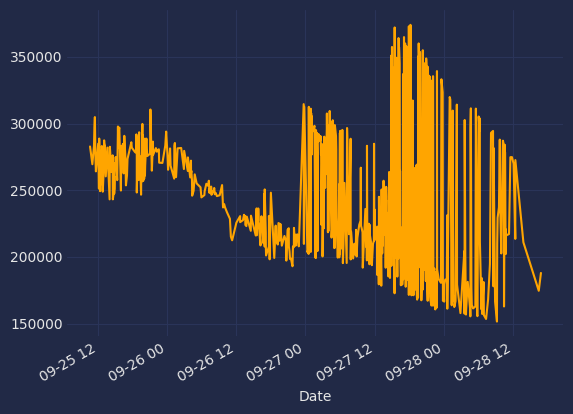

In [193]:
predictions["temperature"].plot(color='orange')
# omni_2017["Speed, km/s"].plot(color='k')

In [137]:
predictions.index.values[...,None].shape

(721, 1)

In [138]:
# Ensure columns are in the right order
predictions = predictions[["bx", "by", "bz", "vx", "vy", "vz", "density", "psw", "temperature", "xgse", "ygse", "zgse", "clock_angle"]]

predictions.to_hdf("../logs/sheath_sw_data_test_for_dagger.h5", key="2017")

/opt/conda/lib/python3.7/site-packages/tables/path.py:137: NaturalNameWarning: object name is not a valid Python identifier: '2017'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


## Plot images and solar wind plots

## AIA images plotted

In [145]:
import sunpy.visualization.colormaps as suncm
import matplotlib as mpl

In [170]:
custom_ctable={}
custom_ctable['211A'] = suncm.cmlist['sdoaia211']
custom_ctable['94A'] = suncm.cmlist['sdoaia94']
custom_ctable['193A'] = suncm.cmlist['sdoaia193']
custom_ctable['335A'] = suncm.cmlist['sdoaia335']
custom_ctable['131A'] = suncm.cmlist['sdoaia131']
custom_ctable['171A'] = suncm.cmlist['sdoaia171']
custom_ctable['304A'] = suncm.cmlist['sdoaia304']
custom_ctable['1600A'] = suncm.cmlist['sdoaia1600']
custom_ctable['1700A'] = suncm.cmlist['sdoaia1700']
custom_ctable['Bx'] = mpl.colormaps['PuOr']
custom_ctable['By'] = mpl.colormaps['PuOr']
custom_ctable['Bz'] = mpl.colormaps['PuOr']
def Color(wv):
    return custom_ctable[wv]

In [175]:
import mplcyberpunk
import os

In [212]:
plt.style.use("dark_background")

In [213]:
plt.rcParams['axes.facecolor'] = 'black'

In [214]:
save_path = "../AIA_movie/"
if not os.path.isdir(save_path):
    os.makedirs(save_path)

100%|██████████| 44/44 [03:51<00:00,  5.25s/it]


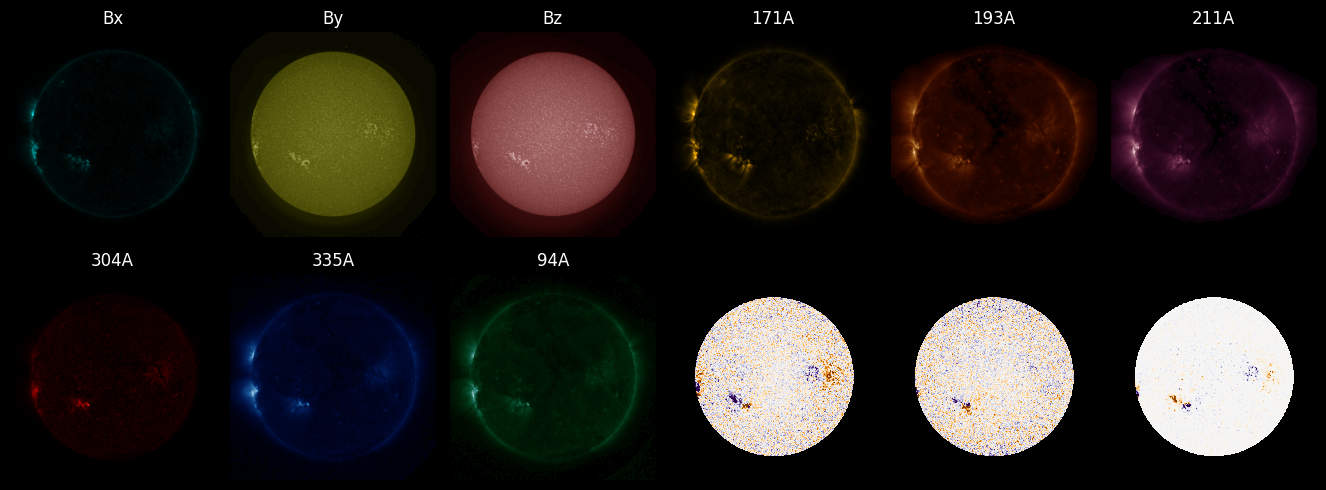

In [218]:
N = aia_data.shape[1]
N_aia = aia_data.shape[0]
fig,ax = plt.subplots(2,6,figsize=(14,5))
ax = ax.ravel()
for ind in tqdm(range(N)):
    for i in range(N_aia):
        ax[i].imshow(aia_data[i,ind,:],cmap=custom_ctable[PASSBANDS[i]],origin='lower')
        ax[i].grid(False)
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].spines['bottom'].set_visible(False)
        ax[i].spines['left'].set_visible(False)
        ax[i].set_title(PASSBANDS[i],color='white')
    N_hmi = hmi_data.shape[0]
    mask = get_mask(n_size = 512)
    for i in range(N_hmi):
        ax[i+N_aia].imshow(hmi_data[i,ind,:]*mask,cmap=custom_ctable[HMICOMPS[i]],origin='lower',vmax=100,vmin=-100)
        ax[i+N_aia].grid(False)
        ax[i+N_aia].set_xticks([])
        ax[i+N_aia].set_yticks([])
        ax[i+N_aia].spines['top'].set_visible(False)
        ax[i+N_aia].spines['right'].set_visible(False)
        ax[i+N_aia].spines['bottom'].set_visible(False)
        ax[i+N_aia].spines['left'].set_visible(False)
        ax[i].set_title(HMICOMPS[i],color='white')
    plt.tight_layout()
    plt.savefig(f"{save_path}AIA_{ind:03d}.png")

## Plot solar wind measurement

In [234]:
save_path = "../SW_movie/"
if not os.path.isdir(save_path):
    os.makedirs(save_path)

In [235]:
plt.style.use("dark_background")
# plt.style.use("cyberpunk")

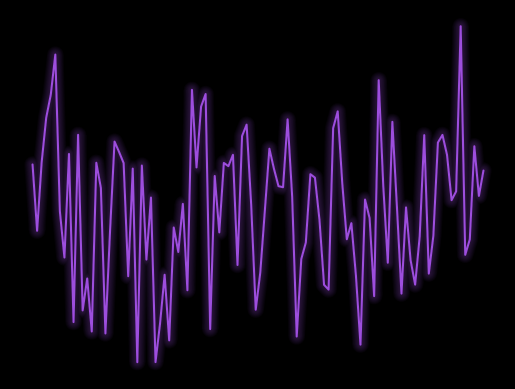

In [236]:
fig,ax = plt.subplots(1,1)
plt.plot(xvalues[:100],predictions["temperature"].values[:100],color=colours[-1])
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
mplcyberpunk.make_lines_glow()


100%|██████████| 206/206 [08:04<00:00,  2.35s/it]


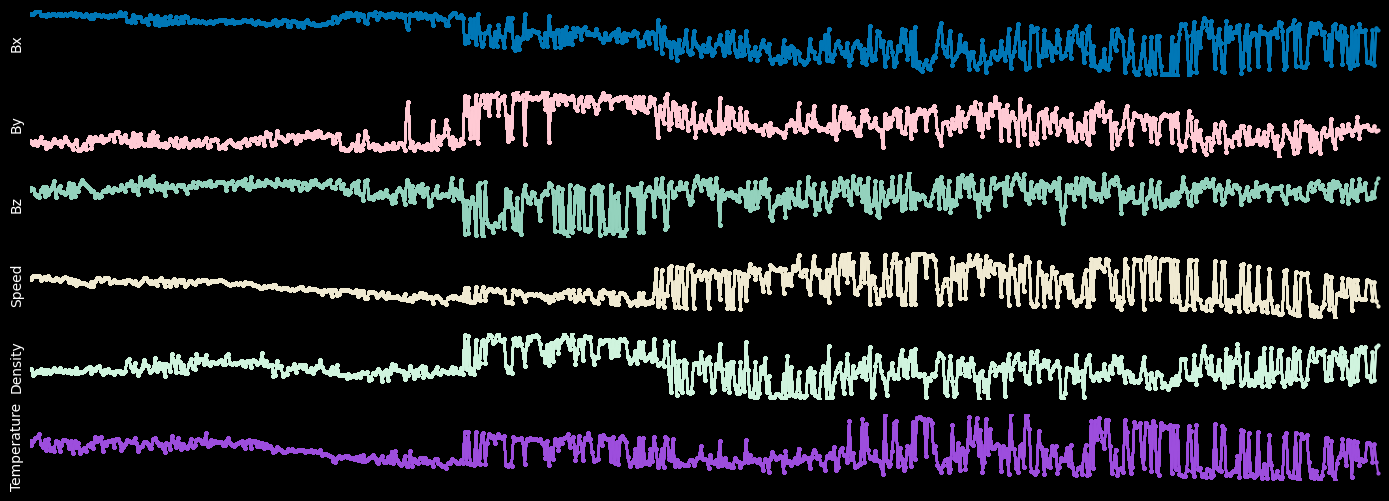

In [239]:
N = aia_data.shape[1]
cols = ['bx','by', 'bz', 'vx', 'density', 'temperature']
titles = ["Bx", "By", "Bz", "Speed", "Density", "Temperature"]
colours = ["#0077b6","#ffcad4","#94d2bd","#f0ead2","#d0f4de","#9d4edd"]
N_values = len(titles)
fig,ax = plt.subplots(N_values,1,figsize=(14,5))
ax = ax.ravel()
dates = predictions.index
xvalues = np.arange(len(dates))    
for ind in tqdm(range(N)[515:]):
    for i in range(N_values):
        ax[i].plot(xvalues[:ind],predictions[cols[i]].values[:ind],color=colours[i],marker='o',markersize=2.0)
        ax[i].grid(False)
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].spines['bottom'].set_visible(False)
        ax[i].spines['left'].set_visible(False)
        ax[i].set_ylabel(titles[i],color='white')
        ax[i].set_xlim([xvalues[0],xvalues[-1]])
        ax[i].set_ylim([np.nanmin(predictions[cols[i]].values),np.nanmax(predictions[cols[i]].values)])
        # mplcyberpunk.make_lines_glow()
    plt.tight_layout()
    plt.savefig(f"{save_path}SW_{ind:03d}.png",dpi=200)

In [187]:
predictions

,bx,by,bz,vx,vy,vz,density,psw,temperature,xgse,ygse,zgse,clock_angle
Date,,,,,,,,,,,,,
2017-09-25 10:39:30.090000+00:00,1.271765,2.142053,0.515188,507.778748,0.0,0.0,2.465894e-20,6.358043e-09,282821.187500,0.0,0.0,0.0,1.334768
2017-09-25 11:03:43.340000+00:00,1.224619,2.044251,0.623681,504.680939,0.0,0.0,2.457741e-20,6.259937e-09,269509.562500,0.0,0.0,0.0,1.274676
2017-09-25 11:20:42.121250+00:00,1.218480,1.932215,0.547689,513.494141,0.0,0.0,2.297326e-20,6.057502e-09,283255.281250,0.0,0.0,0.0,1.294590
2017-09-25 11:23:55.527500+00:00,1.427943,2.130201,0.342804,512.523193,0.0,0.0,2.353128e-20,6.181197e-09,292205.312500,0.0,0.0,0.0,1.411239
2017-09-25 11:24:56.996250+00:00,1.509717,1.856037,0.256201,515.585876,0.0,0.0,2.402303e-20,6.386013e-09,296803.718750,0.0,0.0,0.0,1.433627
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-09-28 12:21:40.590000+00:00,-0.030059,2.779880,0.424399,427.966461,0.0,0.0,2.921566e-20,5.351002e-09,213514.187500,0.0,0.0,0.0,1.419298
2017-09-28 12:22:35.402500+00:00,-2.715396,2.990658,0.193019,492.660065,0.0,0.0,2.170158e-20,5.267276e-09,272615.656250,0.0,0.0,0.0,1.506345
2017-09-28 13:46:03.902500+00:00,0.160137,2.709611,0.836490,425.751648,0.0,0.0,3.054725e-20,5.537130e-09,210924.203125,0.0,0.0,0.0,1.271366


In [147]:
aia_data.shape,hmi_data[0]

((9, 721, 512, 512), (3, 721, 512, 512))